# Notebook 2 - Bureau Data Exploratory Analysis

This notebook explores the bureau dataset, which contains information about the applicants' previous and active credits reported by other financial institutions.

The analysis checks the structure of the data, applicant coverage, missing values, categorical values, numerical distributions and unusual records. It also examines whether parts of an applicant's credit history are related to default.

## Import libraries


In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)
sns.set_style("whitegrid")

BLUE = "#2E6DB4"
ORANGE = "#E67E22"

print("Libraries imported successfully.")


Libraries imported successfully.


## Set file paths


In [5]:
bureau_path = "data/raw/bureau.csv"
application_path = "data/raw/application_train.csv"


## Load the data


In [7]:
bureau = pd.read_csv(bureau_path)
application_target = pd.read_csv(application_path, usecols=["SK_ID_CURR", "TARGET"])

print("bureau shape:", bureau.shape)
print("Training applicants:", len(application_target))
bureau.head()


bureau shape: (1716428, 17)
Training applicants: 307511


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


This file has many more rows than the application file, because one applicant can have several bureau credits. SK_ID_BUREAU is the ID for each credit record, and SK_ID_CURR links it back to the applicant. This data will need to be summarized into one row per applicant later.


## Structure, keys, and duplicate checks


In [10]:
print("Exact duplicate rows:", bureau.duplicated().sum())
print("Duplicate SK_ID_BUREAU values:", bureau["SK_ID_BUREAU"].duplicated().sum())
print("Missing SK_ID_BUREAU values:", bureau["SK_ID_BUREAU"].isna().sum())
print("Missing SK_ID_CURR values:", bureau["SK_ID_CURR"].isna().sum())
print("Unique bureau credits:", bureau["SK_ID_BUREAU"].nunique())
print("Unique applicants in the complete bureau file:", bureau["SK_ID_CURR"].nunique())


Exact duplicate rows: 0
Duplicate SK_ID_BUREAU values: 0
Missing SK_ID_BUREAU values: 0
Missing SK_ID_CURR values: 0
Unique bureau credits: 1716428
Unique applicants in the complete bureau file: 305811


The IDs are clean. There are no duplicate or missing values. There are fewer unique applicants than records because one applicant can have several bureau credits.


In [12]:
numeric_columns = bureau.select_dtypes(include="number").columns.tolist()
categorical_columns = bureau.select_dtypes(exclude="number").columns.tolist()

print("Numeric columns:", len(numeric_columns))
print("Categorical columns:", len(categorical_columns))
print("Categorical column names:", categorical_columns)
bureau.dtypes.astype(str).value_counts().to_frame("column_count")


Numeric columns: 14
Categorical columns: 3
Categorical column names: ['CREDIT_ACTIVE', 'CREDIT_CURRENCY', 'CREDIT_TYPE']


,column_count
float64,8
int64,6
str,3


## Bureau history coverage

Checking how many applicants in the application data have bureau records.


In [14]:
labelled_applicant_ids = set(application_target["SK_ID_CURR"])
bureau_applicant_ids = set(bureau["SK_ID_CURR"])

applicants_with_bureau = labelled_applicant_ids.intersection(bureau_applicant_ids)
applicants_without_bureau = labelled_applicant_ids.difference(bureau_applicant_ids)
other_bureau_applicants = bureau_applicant_ids.difference(labelled_applicant_ids)

coverage_percent = len(applicants_with_bureau) / len(labelled_applicant_ids) * 100

print("Labelled applicants with bureau history:", len(applicants_with_bureau))
print("Bureau-history coverage:", round(coverage_percent, 2), "%")
print("Labelled applicants without bureau history:", len(applicants_without_bureau))
print("Other applicants in the bureau file:", len(other_bureau_applicants))

Labelled applicants with bureau history: 263491
Bureau-history coverage: 85.69 %
Labelled applicants without bureau history: 44020
Other applicants in the bureau file: 42320


85.69% of applicants have bureau history. The extra 42,320 IDs in the bureau file that are not in application_train are probably from the separate test file.


### Default rate with and without bureau history


,count,default_rate_percent
HAS_BUREAU_HISTORY,,
False,44020,10.12
True,263491,7.73


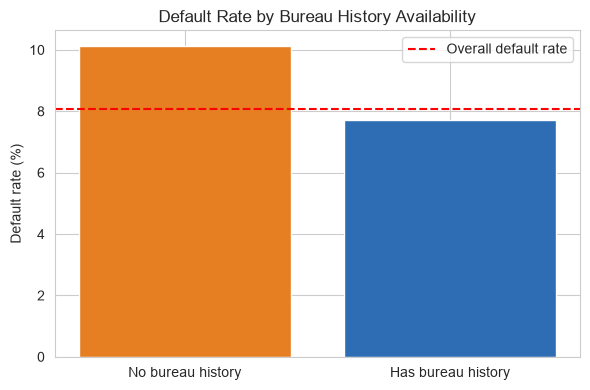

In [17]:
coverage_table = application_target.copy()
coverage_table["HAS_BUREAU_HISTORY"] = coverage_table["SK_ID_CURR"].isin(bureau_applicant_ids)

coverage_default_summary = coverage_table.groupby("HAS_BUREAU_HISTORY")["TARGET"].agg(["count", "mean"])
coverage_default_summary["default_rate_percent"] = coverage_default_summary["mean"] * 100
display(coverage_default_summary.drop(columns="mean").round(2))


plot_values = coverage_default_summary["default_rate_percent"]

plt.figure(figsize=(6, 4))
plt.bar(["No bureau history", "Has bureau history"], plot_values, color=[ORANGE, BLUE])
plt.axhline(application_target["TARGET"].mean() * 100, color="red", linestyle="--", label="Overall default rate")
plt.ylabel("Default rate (%)")
plt.title("Default Rate by Bureau History Availability")
plt.legend()
plt.tight_layout()
plt.show()

Applicants without bureau history default more often. This does not prove that missing history causes default, but it could still be a useful signal.


## Number of bureau credits per applicant


In [20]:
credits_per_applicant = bureau.groupby("SK_ID_CURR")["SK_ID_BUREAU"].count()
credits_per_applicant.describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).to_frame("bureau_credit_count")


,bureau_credit_count
count,305811.000000
mean,5.612709
std,4.430354
min,1.000000
25%,2.000000
50%,4.000000
75%,8.000000
90%,11.000000
95%,14.000000
99%,21.000000


The plot is capped at the 99th percentile so the long tail does not make the main pattern hard to see. Those applicants are still in the data, just not shown on the chart.


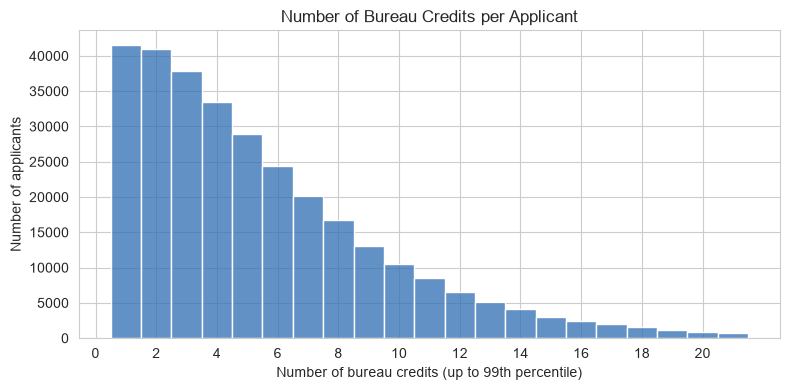

In [22]:
plot_limit = credits_per_applicant.quantile(0.99)

plt.figure(figsize=(8, 4))
sns.histplot(credits_per_applicant[credits_per_applicant <= plot_limit], discrete=True, color=BLUE)
plt.title("Number of Bureau Credits per Applicant")
plt.xlabel("Number of bureau credits (up to 99th percentile)")
plt.ylabel("Number of applicants")
plt.xticks(range(0, int(plot_limit) + 1, 2))
plt.tight_layout()
plt.show()


## Missing-value analysis


Columns containing missing values: 7


,missing_count,missing_percent
AMT_ANNUITY,1226791,71.47
AMT_CREDIT_MAX_OVERDUE,1124488,65.51
DAYS_ENDDATE_FACT,633653,36.92
AMT_CREDIT_SUM_LIMIT,591780,34.48
AMT_CREDIT_SUM_DEBT,257669,15.01
DAYS_CREDIT_ENDDATE,105553,6.15
AMT_CREDIT_SUM,13,0.00


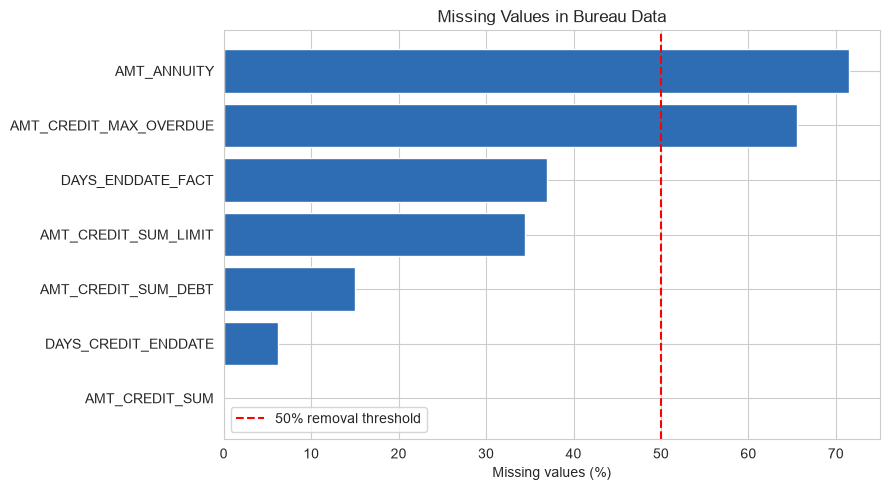

In [24]:
missing_summary = pd.DataFrame({
    "missing_count": bureau.isna().sum(),
    "missing_percent": (bureau.isna().mean() * 100).round(2)
})
missing_summary = missing_summary[missing_summary["missing_count"] > 0]
missing_summary = missing_summary.sort_values("missing_percent", ascending=False)

print("Columns containing missing values:", len(missing_summary))
display(missing_summary)

plt.figure(figsize=(9, 5))
plt.barh(missing_summary.index[::-1], missing_summary["missing_percent"][::-1], color=BLUE)
plt.axvline(50, color="red", linestyle="--", label="50% removal threshold")
plt.legend()
plt.title("Missing Values in Bureau Data")
plt.xlabel("Missing values (%)")
plt.tight_layout()
plt.show()

AMT_ANNUITY and AMT_CREDIT_MAX_OVERDUE are the only two columns with more than 50% missing values. These are the main candidates to drop. The rest will get a closer look during cleaning.


## Categorical feature analysis


In [27]:
for column in categorical_columns:
    category_table = bureau[column].value_counts(dropna=False).to_frame("count")
    category_table["percent"] = category_table["count"] / len(bureau) * 100
    print("\n", column)
    display(category_table.round(2))



 CREDIT_ACTIVE


,count,percent
CREDIT_ACTIVE,,
Closed,1079273,62.88
Active,630607,36.74
Sold,6527,0.38
Bad debt,21,0.00



 CREDIT_CURRENCY


,count,percent
CREDIT_CURRENCY,,
currency 1,1715020,99.92
currency 2,1224,0.07
currency 3,174,0.01
currency 4,10,0.00



 CREDIT_TYPE


,count,percent
CREDIT_TYPE,,
Consumer credit,1251615,72.92
Credit card,402195,23.43
Car loan,27690,1.61
Mortgage,18391,1.07
Microloan,12413,0.72
Loan for business development,1975,0.12
Another type of loan,1017,0.06
Unknown type of loan,555,0.03
Loan for working capital replenishment,469,0.03


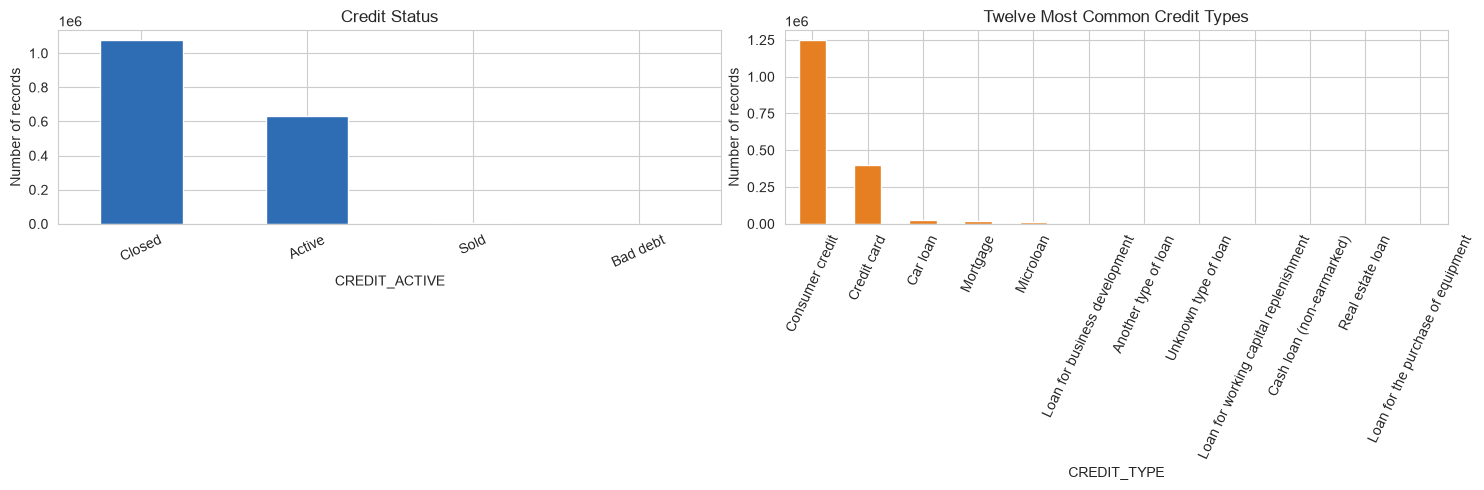

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

bureau["CREDIT_ACTIVE"].value_counts().plot(kind="bar", ax=axes[0], color=BLUE)
axes[0].set_title("Credit Status")
axes[0].set_ylabel("Number of records")
axes[0].tick_params(axis="x", rotation=25)

bureau["CREDIT_TYPE"].value_counts().head(12).plot(kind="bar", ax=axes[1], color=ORANGE)
axes[1].set_title("Twelve Most Common Credit Types")
axes[1].set_ylabel("Number of records")
axes[1].tick_params(axis="x", rotation=65)

plt.tight_layout()
plt.show()


Most credits are closed or active, and almost everything uses currency 1. Consumer credit and credit cards are the most common credit types. The rare credit types can be grouped into an "Other" category during cleaning.


## Numerical summary and domain checks


In [31]:
analysis_numeric_columns = [column for column in numeric_columns if column not in ["SK_ID_CURR", "SK_ID_BUREAU"]]

numeric_summary = bureau[analysis_numeric_columns].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T

numeric_summary[["count", "mean", "std", "min", "1%", "50%", "99%", "max"]]


,count,mean,std,min,1%,50%,99%,max
DAYS_CREDIT,1716428.0,-1142.107685,7.951649e+02,-2922.000,-2867.0,-987.0,-3.800000e+01,0.000000e+00
CREDIT_DAY_OVERDUE,1716428.0,0.818167,3.654443e+01,0.000,0.0,0.0,0.000000e+00,2.792000e+03
DAYS_CREDIT_ENDDATE,1610875.0,510.517362,4.994220e+03,-42060.000,-2571.0,-330.0,3.102900e+04,3.119900e+04
DAYS_ENDDATE_FACT,1082775.0,-1017.437148,7.140106e+02,-42023.000,-2639.0,-897.0,-2.400000e+01,0.000000e+00
AMT_CREDIT_MAX_OVERDUE,591940.0,3825.417661,2.060316e+05,0.000,0.0,0.0,4.198875e+04,1.159872e+08
CNT_CREDIT_PROLONG,1716428.0,0.006410,9.622391e-02,0.000,0.0,0.0,0.000000e+00,9.000000e+00
AMT_CREDIT_SUM,1716415.0,354994.591918,1.149811e+06,0.000,0.0,125518.5,3.700916e+06,5.850000e+08
AMT_CREDIT_SUM_DEBT,1458759.0,137085.119952,6.774011e+05,-4705600.320,0.0,0.0,2.259728e+06,1.701000e+08
AMT_CREDIT_SUM_LIMIT,1124648.0,6229.514980,4.503203e+04,-586406.115,0.0,0.0,1.996206e+05,4.705600e+06
AMT_CREDIT_SUM_OVERDUE,1716428.0,37.912758,5.937650e+03,0.000,0.0,0.0,0.000000e+00,3.756681e+06


### Basic validity checks

Simple checks based on what these columns should look like. Dates should not be in the future, and amounts should not be negative. Nothing is removed automatically, since some unusual values could be real, for example fees or corrections.


In [33]:
domain_checks = pd.DataFrame({
    "check": [
        "Future credit start date",
        "Future actual end date",
        "Future credit update date",
        "Extreme planned end-date code",
        "Extreme actual end-date code",
        "Extreme update-date code",
        "Negative credit amount",
        "Negative debt amount",
        "Negative credit limit",
        "Negative overdue amount",
        "Debt greater than credit amount",
        "Overdue days but zero overdue amount"
    ],
    "rows_affected": [
        (bureau["DAYS_CREDIT"] > 0).sum(),
        (bureau["DAYS_ENDDATE_FACT"] > 0).sum(),
        (bureau["DAYS_CREDIT_UPDATE"] > 0).sum(),
        (bureau["DAYS_CREDIT_ENDDATE"].abs() > 36500).sum(),
        (bureau["DAYS_ENDDATE_FACT"].abs() > 36500).sum(),
        (bureau["DAYS_CREDIT_UPDATE"].abs() > 36500).sum(),
        (bureau["AMT_CREDIT_SUM"] < 0).sum(),
        (bureau["AMT_CREDIT_SUM_DEBT"] < 0).sum(),
        (bureau["AMT_CREDIT_SUM_LIMIT"] < 0).sum(),
        (bureau["AMT_CREDIT_SUM_OVERDUE"] < 0).sum(),
        (bureau["AMT_CREDIT_SUM_DEBT"] > bureau["AMT_CREDIT_SUM"]).sum(),
        (
            (bureau["CREDIT_DAY_OVERDUE"] > 0) &
            (bureau["AMT_CREDIT_SUM_OVERDUE"] == 0)
        ).sum()
    ]
})

domain_checks

,check,rows_affected
0,Future credit start date,0
1,Future actual end date,0
2,Future credit update date,17
3,Extreme planned end-date code,134
4,Extreme actual end-date code,1
5,Extreme update-date code,95
6,Negative credit amount,0
7,Negative debt amount,8418
8,Negative credit limit,351
9,Negative overdue amount,0


The date issues will be fixed during cleaning. Negative debt, negative limit, and debt higher than credit are not automatically wrong. These could be overpayments or interest, so they will be flagged instead of removed.


## Extreme-value review


In [36]:
important_amount_columns = [
    "AMT_CREDIT_MAX_OVERDUE",
    "AMT_CREDIT_SUM",
    "AMT_CREDIT_SUM_DEBT",
    "AMT_CREDIT_SUM_LIMIT",
    "AMT_CREDIT_SUM_OVERDUE",
    "AMT_ANNUITY",
]

numeric_summary.loc[important_amount_columns, ["min", "1%", "50%", "99%", "max"]]


,min,1%,50%,99%,max
AMT_CREDIT_MAX_OVERDUE,0.000,0.0,0.0,4.198875e+04,1.159872e+08
AMT_CREDIT_SUM,0.000,0.0,125518.5,3.700916e+06,5.850000e+08
AMT_CREDIT_SUM_DEBT,-4705600.320,0.0,0.0,2.259728e+06,1.701000e+08
AMT_CREDIT_SUM_LIMIT,-586406.115,0.0,0.0,1.996206e+05,4.705600e+06
AMT_CREDIT_SUM_OVERDUE,0.000,0.0,0.0,0.000000e+00,3.756681e+06
AMT_ANNUITY,0.000,0.0,0.0,1.184519e+05,1.184534e+08


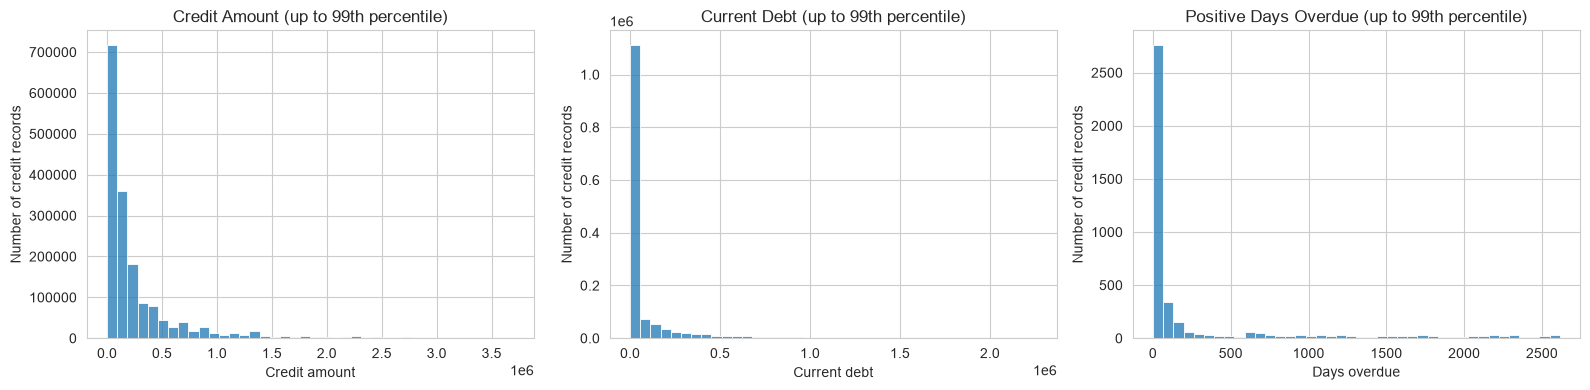

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

credit_limit = bureau["AMT_CREDIT_SUM"].quantile(0.99)
debt_limit = bureau["AMT_CREDIT_SUM_DEBT"].quantile(0.99)
positive_overdue = bureau.loc[bureau["CREDIT_DAY_OVERDUE"] > 0, "CREDIT_DAY_OVERDUE"]
overdue_limit = positive_overdue.quantile(0.99)

sns.histplot(bureau.loc[bureau["AMT_CREDIT_SUM"].between(0, credit_limit), "AMT_CREDIT_SUM"], bins=40, ax=axes[0])
sns.histplot(bureau.loc[bureau["AMT_CREDIT_SUM_DEBT"].between(0, debt_limit), "AMT_CREDIT_SUM_DEBT"], bins=40, ax=axes[1])
sns.histplot(positive_overdue[positive_overdue <= overdue_limit], bins=40, ax=axes[2])

axes[0].set_title("Credit Amount (up to 99th percentile)")
axes[1].set_title("Current Debt (up to 99th percentile)")
axes[2].set_title("Positive Days Overdue (up to 99th percentile)")

axes[0].set_xlabel("Credit amount")
axes[1].set_xlabel("Current debt")
axes[2].set_xlabel("Days overdue")

axes[0].set_ylabel("Number of credit records")
axes[1].set_ylabel("Number of credit records")
axes[2].set_ylabel("Number of credit records")

plt.tight_layout()
plt.show()

All three are right-skewed, with mostly small or moderate values and a few very large ones. The plot is capped at the 99th percentile, but the original values stay in the data.


## Applicant-level target comparison

Bureau has multiple rows per applicant, so a few quick applicant-level summaries are created just for this comparison. These are not the final features.


In [40]:
bureau_for_analysis = bureau[bureau["SK_ID_CURR"].isin(labelled_applicant_ids)].copy()

bureau_for_analysis["IS_ACTIVE"] = (bureau_for_analysis["CREDIT_ACTIVE"] == "Active").astype(int)
bureau_for_analysis["IS_CLOSED"] = (bureau_for_analysis["CREDIT_ACTIVE"] == "Closed").astype(int)
bureau_for_analysis["IS_BAD_DEBT"] = (bureau_for_analysis["CREDIT_ACTIVE"] == "Bad debt").astype(int)
bureau_for_analysis["HAS_OVERDUE_DAYS"] = (bureau_for_analysis["CREDIT_DAY_OVERDUE"] > 0).astype(int)
bureau_for_analysis["HAS_OVERDUE_AMOUNT"] = (bureau_for_analysis["AMT_CREDIT_SUM_OVERDUE"] > 0).astype(int)
bureau_for_analysis["POSITIVE_DEBT"] = bureau_for_analysis["AMT_CREDIT_SUM_DEBT"].clip(lower=0)

applicant_bureau = bureau_for_analysis.groupby("SK_ID_CURR").agg(
    BUREAU_CREDIT_COUNT=("SK_ID_BUREAU", "count"),
    ACTIVE_CREDIT_COUNT=("IS_ACTIVE", "sum"),
    CLOSED_CREDIT_COUNT=("IS_CLOSED", "sum"),
    HAS_BAD_DEBT=("IS_BAD_DEBT", "max"),
    HAS_OVERDUE_DAYS=("HAS_OVERDUE_DAYS", "max"),
    HAS_OVERDUE_AMOUNT=("HAS_OVERDUE_AMOUNT", "max"),
    TOTAL_POSITIVE_DEBT=("POSITIVE_DEBT", "sum"),
    MAX_DAYS_OVERDUE=("CREDIT_DAY_OVERDUE", "max"),
    MOST_RECENT_CREDIT_DAYS=("DAYS_CREDIT", "max"),
).reset_index()

applicant_bureau.head()


,SK_ID_CURR,BUREAU_CREDIT_COUNT,ACTIVE_CREDIT_COUNT,CLOSED_CREDIT_COUNT,HAS_BAD_DEBT,HAS_OVERDUE_DAYS,HAS_OVERDUE_AMOUNT,TOTAL_POSITIVE_DEBT,MAX_DAYS_OVERDUE,MOST_RECENT_CREDIT_DAYS
0,100002,8,2,6,0,0,0,245781.0,0,-103
1,100003,4,1,3,0,0,0,0.0,0,-606
2,100004,2,0,2,0,0,0,0.0,0,-408
3,100007,1,0,1,0,0,0,0.0,0,-1149
4,100008,3,1,2,0,0,0,240057.0,0,-78


### Applicant-level default comparisons


In [42]:
applicant_bureau_target = application_target.merge(applicant_bureau, on="SK_ID_CURR", how="left")

binary_features = ["HAS_BAD_DEBT", "HAS_OVERDUE_DAYS", "HAS_OVERDUE_AMOUNT"]
binary_default_results = []

for feature in binary_features:
    temporary = applicant_bureau_target.dropna(subset=[feature])
    for value, group in temporary.groupby(feature):
        binary_default_results.append({
            "feature": feature,
            "value": int(value),
            "applicant_count": len(group),
            "default_rate_percent": group["TARGET"].mean() * 100
        })

binary_default_table = pd.DataFrame(binary_default_results)
binary_default_table["interpret_with_caution"] = binary_default_table["applicant_count"] < 100
binary_default_table.round(2)


,feature,value,applicant_count,default_rate_percent,interpret_with_caution
0,HAS_BAD_DEBT,0,263471,7.73,False
1,HAS_BAD_DEBT,1,20,20.00,True
2,HAS_OVERDUE_DAYS,0,260094,7.62,False
3,HAS_OVERDUE_DAYS,1,3397,15.90,False
4,HAS_OVERDUE_AMOUNT,0,260157,7.62,False
5,HAS_OVERDUE_AMOUNT,1,3334,16.20,False


The bad-debt group has only 20 applicants, so its 20% default rate is not very reliable. Overdue days and overdue amount look like a stronger signal.


In [44]:
applicant_feature_columns = [
    "BUREAU_CREDIT_COUNT",
    "ACTIVE_CREDIT_COUNT",
    "CLOSED_CREDIT_COUNT",
    "TOTAL_POSITIVE_DEBT",
    "MAX_DAYS_OVERDUE",
    "MOST_RECENT_CREDIT_DAYS",
]

applicant_correlations = applicant_bureau_target[applicant_feature_columns + ["TARGET"]].corr()["TARGET"].drop("TARGET")
applicant_correlations.sort_values().to_frame("correlation_with_target").round(4)


,correlation_with_target
CLOSED_CREDIT_COUNT,-0.0308
BUREAU_CREDIT_COUNT,0.0041
MAX_DAYS_OVERDUE,0.0055
TOTAL_POSITIVE_DEBT,0.0071
MOST_RECENT_CREDIT_DAYS,0.0498
ACTIVE_CREDIT_COUNT,0.0671


All of these correlations are weak by themselves. This does not mean the features are useless, they may still help when combined with other features.


## Main findings

The bureau dataset contains multiple credit records for each applicant, so it will need to be summarized before it can be merged with the application data.

The main findings from this analysis are:

- The bureau identifiers are complete and unique.
- Bureau history is available for 85.69% of labelled applicants.
- Applicants have a median of 4 bureau credits.
- Two columns contain more than 50% missing values.
- Some currencies and credit types occur very rarely.
- A small number of date values appear invalid.
- Negative debt and credit-limit values exist and require careful handling.
- The financial columns contain some very large values.
- Previous overdue behaviour is associated with a higher default rate.
- Credit count, status, debt and overdue history may be useful when applicant-level features are created.

Based on these findings, the cleaning stage will remove out-of-scope records, combine rare categories, correct clearly invalid dates, remove features with very high missingness and retain unusual financial records with indicator columns where appropriate.